Tadas Riksas 2312087 ResNet, Ambulance, Banana, Parachute. With picture similarity comparison thing.

In [3]:
pip install torch torchvision scikit-image numpy matplotlib==3.10.8 pandas openimages seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [126]:
import os
from torch import Generator
import torch
import pandas as pd
from skimage import io, transform
from skimage.color import gray2rgb
from skimage.transform import resize
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, utils
from openimages.download import download_dataset
import torchvision.models as models
import glob
import torch.nn as nn   
from PIL import Image
from sklearn.metrics import classification_report
import seaborn as sns
import math


In [127]:
data_dir = "./project/data/"

# TODO - increase in production
number_of_samples = 334
classes = ["Ambulance", "Banana", "Parachute"]
mappings = [407, 954, 701]

NUM_CLASSES = len(classes)

if not os.path.exists(data_dir):
    os.makedirs(data_dir)
    
print("Downloading data...")
# download_dataset(
#     data_dir,
#     classes,
#     limit=number_of_samples,
# )

In [128]:
IMAGE_SIZE = 380

base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

augment_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225]),
])

In [129]:
def read_img(file_name):
    return Image.open(file_name).convert("RGB")

In [130]:
class MyImages(Dataset):
    def __init__(self, path, augment=False):
        self.path = path
        self.images = os.listdir(path)
        self.augment = augment

        self.class1_files = glob.glob(self.path + "/{}/images/*.jpg".format(classes[0].lower()))
        self.class2_files = glob.glob(self.path + "/{}/images/*.jpg".format(classes[1].lower()))
        self.class3_files = glob.glob(self.path + "/{}/images/*.jpg".format(classes[2].lower()))
        
        # include only the number of samples specified
        self.class1_files = self.class1_files[:number_of_samples]
        self.class2_files = self.class2_files[:number_of_samples]
        self.class3_files = self.class3_files[:number_of_samples]
        
        self.class1 = len(self.class1_files)
        self.class2 = len(self.class2_files)
        self.class3 = len(self.class3_files)
        
        self.files = self.class1_files + self.class2_files + self.class3_files
        
        self.labels = [0] * self.class1 + [1] * self.class2 + [2] * self.class3
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        img = read_img(self.files[idx])
        label = self.labels[idx]
        
        transform = augment_transform if self.augment else base_transform
        img = transform(img)
        return img, label


In [131]:
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
SEED = 1
BATCH_SIZE = 32

def get_dataloaders():
    full_dataset = MyImages(data_dir)
    
    train_size = math.floor(TRAIN_SPLIT * len(full_dataset))
    val_size = math.floor(VAL_SPLIT * len(full_dataset))
    
    indices = torch.randperm(len(full_dataset), generator=Generator().manual_seed(SEED))

    train_idx = indices[:train_size]
    val_idx   = indices[train_size:train_size + val_size]
    test_idx  = indices[train_size + val_size:]

    train_ds = torch.utils.data.Subset(MyImages(data_dir, augment=True), train_idx) # type: ignore
    val_ds   = torch.utils.data.Subset(MyImages(data_dir, augment=False), val_idx) # type: ignore
    test_ds  = torch.utils.data.Subset(MyImages(data_dir, augment=False), test_idx) # type: ignore
    
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True, prefetch_factor=2)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True, prefetch_factor=2)
    
    return train_loader, val_loader, test_loader

In [132]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            # we want the input x to match dimmensions with all the calculations above so we can add it
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
            
    def forward(self, x):
        identity = x
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out += identity
        out = self.relu(out)
        
        return out
        
        
class MiniResNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = ResidualBlock(64, 64, stride=1)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.layer3 = ResidualBlock(128, 256, stride=2)
        # self.layer4 = ResidualBlock(256, 512, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        # x = self.layer4(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        
        return x 

In [145]:
NUM_EPOCHS    = 150
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "best_model.pth"

def train_model(model, train_loader, val_loader):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    training_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []
    
    best_val_acc = 0.0
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)
            
        train_loss = running_loss / total_train
        train_accuracy = correct_train / total_train
        
        # Validation loop
        running_loss_v = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images  = images.to(DEVICE)
                labels  = labels.to(DEVICE)
                outputs = model(images)
                loss    = criterion(outputs, labels)

                running_loss_v += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        val_loss = running_loss_v / total_val
        val_acc = correct_val / total_val
        
        scheduler.step(val_loss)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), MODEL_PATH)
            
        training_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        train_acc_history.append(train_accuracy)
        val_acc_history.append(val_acc)
    
    return (training_loss_history, val_loss_history, train_acc_history, val_acc_history)


In [146]:
train_loader, val_loader, test_loader = get_dataloaders()

In [147]:
model = MiniResNet().to(DEVICE)
history = train_model(model, train_loader, val_loader)

In [148]:
def plot_training_history(history):
    training_loss_history, val_loss_history, train_acc_history, val_acc_history = history
    
    epochs = range(1, NUM_EPOCHS + 1)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, training_loss_history, label='Training Loss')
    plt.plot(epochs, val_loss_history, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_acc_history, label='Training Accuracy')
    plt.plot(epochs, val_acc_history, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

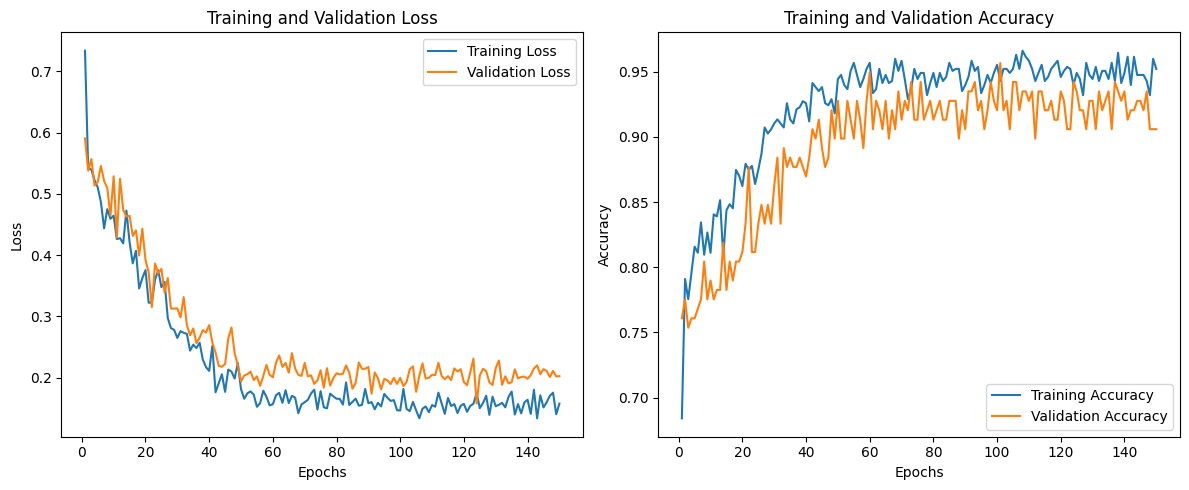

In [149]:
plot_training_history(history)

In [150]:
from sklearn.metrics import confusion_matrix


model = MiniResNet(num_classes=NUM_CLASSES)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

model.to(DEVICE)

all_predictions, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(DEVICE))
        probs = torch.nn.functional.softmax(outputs, dim=1)
        all_predictions.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())


all_predictions = np.concatenate(all_predictions)
all_labels = np.concatenate(all_labels) 

print("Predictions shape:", (all_predictions).shape)
print("Labels shape:", (all_labels).shape)

print(all_predictions)
print(all_labels)

Predictions shape: (139, 3)
Labels shape: (139,)
[[7.66867846e-02 9.14522350e-01 8.79088324e-03]
 [3.35517048e-04 7.56478356e-03 9.92099702e-01]
 [9.99945760e-01 4.46484009e-05 9.58552209e-06]
 [7.34147325e-05 2.16056178e-05 9.99904990e-01]
 [4.27169446e-03 1.03043055e-03 9.94697809e-01]
 [1.40198914e-04 1.32594362e-03 9.98533845e-01]
 [6.91491150e-05 1.25223681e-01 8.74707162e-01]
 [5.83869731e-03 7.44940201e-03 9.86711860e-01]
 [9.60314355e-06 9.98449564e-01 1.54085178e-03]
 [1.50599926e-05 9.99779880e-01 2.05078104e-04]
 [3.13840946e-03 2.20337161e-03 9.94658291e-01]
 [2.55732358e-01 1.54336795e-01 5.89930832e-01]
 [3.08784001e-05 9.98676717e-01 1.29243848e-03]
 [3.63760453e-04 2.49385223e-04 9.99386907e-01]
 [3.11892363e-05 1.16400974e-04 9.99852300e-01]
 [5.22337593e-02 5.32935653e-03 9.42436993e-01]
 [4.40607764e-05 9.98021126e-01 1.93484232e-03]
 [7.50589743e-02 3.57021570e-01 5.67919493e-01]
 [9.99766052e-01 2.02023191e-04 3.19561732e-05]
 [3.79091907e-05 9.49826896e-01 5.01352

              precision    recall  f1-score   support

   Ambulance       0.88      0.90      0.89        39
      Banana       0.96      0.88      0.92        50
   Parachute       0.89      0.94      0.91        50

    accuracy                           0.91       139
   macro avg       0.91      0.91      0.91       139
weighted avg       0.91      0.91      0.91       139



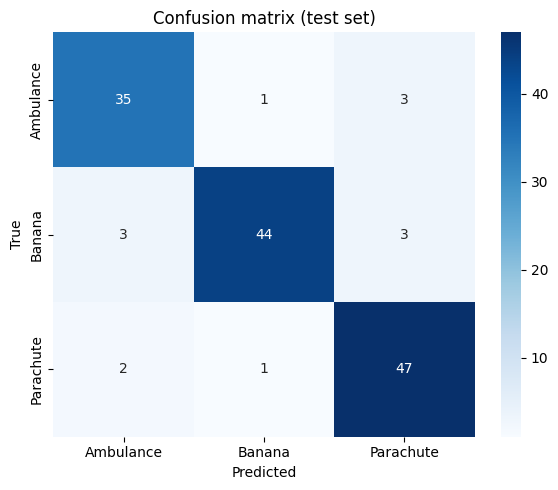

In [151]:
all_pred_classes = np.argmax(all_predictions, axis=1)

print(classification_report(all_labels, all_pred_classes, target_names=classes))
cm = confusion_matrix(all_labels, all_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion matrix (test set)')
plt.tight_layout()
plt.show()

In [152]:

def classify_with_threshold(predictions, true_labels, class_idx: int, threshold=0.5):
    """
    Classify samples based on threshold for a specific class
    # """
    
    # find indexes where true_labels == class_idx
    class_probs = predictions[:, class_idx]
    predicted = (class_probs >= threshold).astype(int)
    true = (true_labels == class_idx).astype(int)
    
    # Calculate metrics
    tp = np.sum((predicted == 1) & (true == 1))
    fp = np.sum((predicted == 1) & (true == 0))
    fn = np.sum((predicted == 0) & (true == 1))
    tn = np.sum((predicted == 0) & (true == 0))
    
    accuracy = (tp + tn) / len(true) if len(true) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [153]:

T_list = np.concatenate([
    np.linspace(0.05, 0.7, 15),  
    np.linspace(0.7, 1, 15),
])
results = {class_name: [] for class_name in classes}

for j in range(3):
    for T in T_list:
        metrics = classify_with_threshold(
            all_predictions, 
            all_labels, 
            j,
            threshold=T
        )
        results[classes[j]].append(metrics['f1'])
    
    # Find optimal threshold
    idx = np.argmax(results[classes[j]])
    print(f"Optimal T={T_list[idx]:.2f} for {classes[j]} (F1={results[classes[j]][idx]:.3f})")

Optimal T=0.56 for Ambulance (F1=0.897)
Optimal T=0.37 for Banana (F1=0.922)
Optimal T=0.65 for Parachute (F1=0.928)


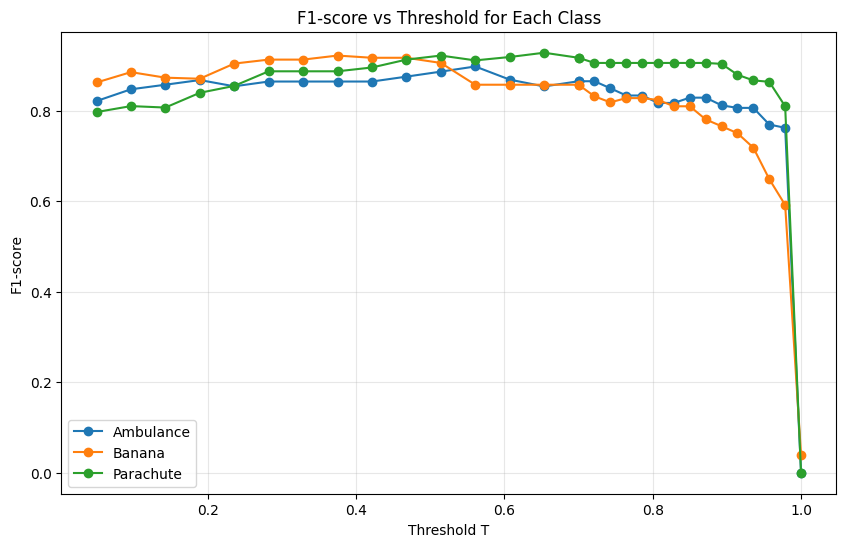

In [154]:
plt.figure(figsize=(10, 6))

for class_name in classes:
    plt.plot(T_list, results[class_name], marker='o', label=class_name)

plt.xlabel("Threshold T")
plt.ylabel("F1-score")
plt.title("F1-score vs Threshold for Each Class")
plt.legend()
plt.grid(True, alpha=0.3)
# limit y above 0.5 for better visualization
# plt.ylim(0.45, 1)
# plt.tight_layout()
plt.show()

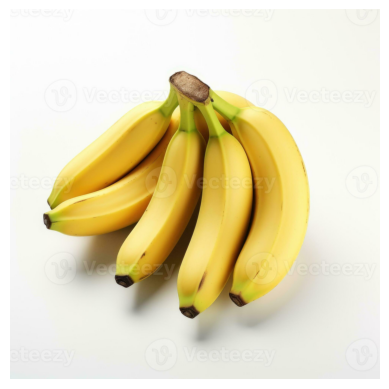

[[1.7594393e-05 9.9748176e-01 2.5006533e-03]]


In [155]:
# select one image not from the training set and test the model on it
# download an image of a house
# spec_img = "./project/train-station.jpg"
# spec_img = "./project/fundog.png"
# spec_img = "./project/bugdog.webp"
# spec_img = "./project/winfun.png"
spec_img = "./project/banana.jpg"
image = io.imread(spec_img)
plt.imshow(image)
plt.axis('off')
plt.show()

# test model on the image
img_tensor = base_transform(read_img(spec_img)).unsqueeze(0).to(DEVICE)
probabilities = model(img_tensor)
probabilities = torch.nn.functional.softmax(probabilities, dim=1)
print(probabilities.detach().cpu().numpy())


# test autocomplete or not

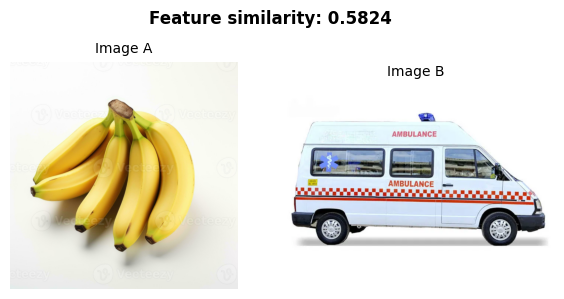

Similarity score: 0.5824 → Not similar


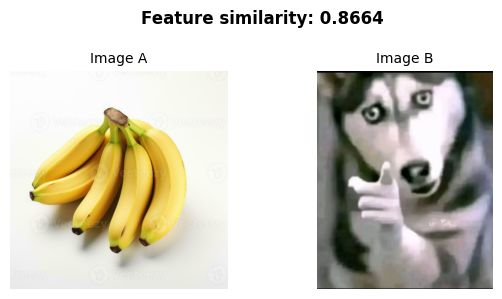

Similarity score: 0.8664 → Very similar


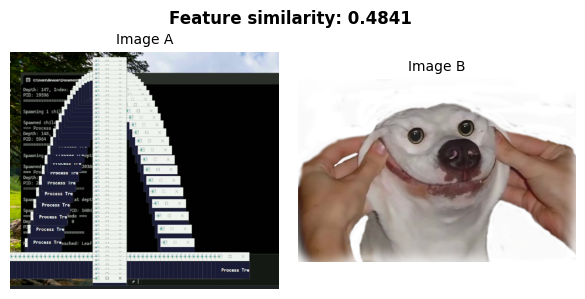

Similarity score: 0.4841 → Not similar


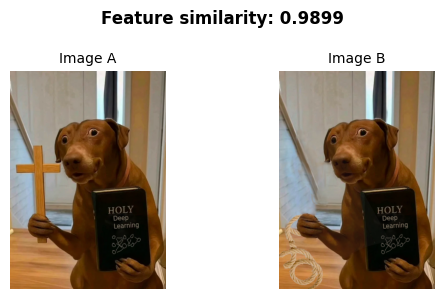

Similarity score: 0.9899 → Very similar


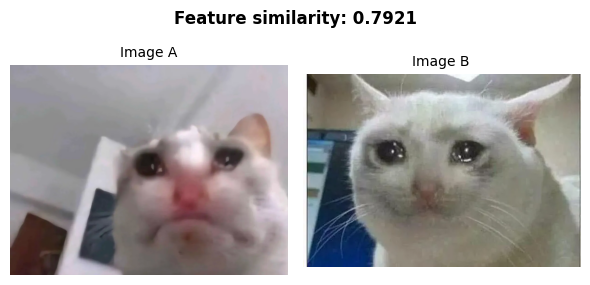

Similarity score: 0.7921 → Somewhat similar


In [156]:
class FeatureExtractor(nn.Module):
    def __init__(self, backbone: MiniResNet):
        super().__init__()
        # No final fc layer
        self.features = nn.Sequential(
            backbone.conv1, 
            backbone.bn1, 
            backbone.relu, 
            backbone.maxpool,
            backbone.layer1, 
            backbone.layer2, 
            backbone.layer3,
            # backbone.layer4,
            backbone.avgpool,
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)    
        # ∥x∥=1
        x = nn.functional.normalize(x, dim=1) 
        return x


def extract_embedding(img_path, extractor, device):
    extractor.eval()
    with torch.no_grad():
        img_tensor = base_transform(read_img(img_path)).unsqueeze(0).to(device)
        emb = extractor(img_tensor)
    return emb.cpu().numpy().squeeze()


def compare_images(img_path_a, img_path_b, extractor, device):
    """
    Compare two images using high-level feature similarity.
    Returns cosine similarity in [-1, 1], higher = more similar.
    """
    emb_a = extract_embedding(img_path_a, extractor, device)
    emb_b = extract_embedding(img_path_b, extractor, device)

    similarity = float(np.dot(emb_a, emb_b))

    return similarity


def visualise_comparison(img_path_a, img_path_b, similarity):
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))

    axes[0].imshow(io.imread(img_path_a))
    axes[0].set_title("Image A", fontsize=10)
    axes[0].axis("off")

    axes[1].imshow(io.imread(img_path_b))
    axes[1].set_title("Image B", fontsize=10)
    axes[1].axis("off")

    fig.suptitle(f"Feature similarity: {similarity:.4f}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    if similarity > 0.85:
        verdict = "Very similar"
    elif similarity > 0.6:
        verdict = "Somewhat similar"
    else:
        verdict = "Not similar"
    print(f"Similarity score: {similarity:.4f} → {verdict}")



best_model = MiniResNet(num_classes=NUM_CLASSES)
best_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
best_model.to(DEVICE)
extractor = FeatureExtractor(best_model).to(DEVICE)

img_a1 = "./project/banana.jpg"
img_b1 = "./project/ambulance.webp"

similarity = compare_images(img_a1, img_b1, extractor, DEVICE)
visualise_comparison(img_a1, img_b1, similarity)

img_a1 = "./project/banana.jpg"
img_b1 = "./project/dog3.webp"

similarity = compare_images(img_a1, img_b1, extractor, DEVICE)
visualise_comparison(img_a1, img_b1, similarity)

img_a1 = "./project/winfun.png"
img_b1 = "./project/fundog.png"

similarity = compare_images(img_a1, img_b1, extractor, DEVICE)
visualise_comparison(img_a1, img_b1, similarity)

img_a2 = "./project/dog1.webp"
img_b2 = "./project/dog2.png"

similarity = compare_images(img_a2, img_b2, extractor, DEVICE)
visualise_comparison(img_a2, img_b2, similarity)

img_a2 = "./project/cat1.png"
img_b2 = "./project/cat2.webp"

similarity = compare_images(img_a2, img_b2, extractor, DEVICE)
visualise_comparison(img_a2, img_b2, similarity)
